In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    number_1: int
    operator: str
    number_2: int
    result: int

In [3]:
def adder(state: AgentState) -> AgentState:
    state["result"] = state["number_1"] + state["number_2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    state["result"] = state["number_1"] - state["number_2"]
    return state
def decider(state: AgentState) -> AgentState:
    if state["operator"] == "+":
        return "add"
    elif state["operator"] == "-":
        return "subtract"

In [4]:
graph = StateGraph(AgentState)

In [5]:
graph.add_node("adder_node", adder)
graph.add_node("subtractor_node", subtractor)
graph.add_node("decider_node", lambda state: state)


graph.set_entry_point("decider_node")

graph.add_conditional_edges("decider_node", decider,
                                {
        "add": "adder_node",
        "subtract": "subtractor_node"
    }
)

graph.set_finish_point("adder_node")
graph.set_finish_point("subtractor_node")

In [6]:
test = graph.compile()

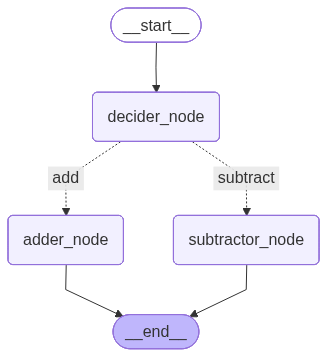

In [7]:
test

In [8]:
babu = test.invoke({"number_1": 5, "operator": "-", "number_2": 3})

In [ ]:
babu

{'number_1': 5, 'operator': '-', 'number_2': 3, 'result': 2}

: 